## Eksperiment1-Originalni Whisper

In [1]:
import whisper
import time
import wave
import pandas as pd
from pathlib import Path

In [2]:
import os
os.environ["PATH"] += r";D:\anaconda\envs\whisper_test\Library\bin"

In [3]:
AUDIO_FOLDER = Path("audio")
REZULTATI_FOLDER = Path("rezultati")
REZULTATI_FOLDER.mkdir(exist_ok=True)

audio_fajlovi = [
    "govor10.wav",
    "govor30.wav",
    "govor60.wav"
]

In [4]:
for fajl in audio_fajlovi:
    putanja = AUDIO_FOLDER / fajl
    print(fajl, "POSTOJI" if putanja.exists() else "NE POSTOJI")

govor10.wav POSTOJI
govor30.wav POSTOJI
govor60.wav POSTOJI


In [5]:
def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as f:
        frames = f.getnframes()
        rate = f.getframerate()
        return frames / float(rate)

In [6]:
for fajl in audio_fajlovi:
    putanja = AUDIO_FOLDER / fajl
    trajanje = trajanje_wav(putanja)
    print(f"{fajl}: {trajanje:.2f} s")

govor10.wav: 11.06 s
govor30.wav: 24.89 s
govor60.wav: 66.65 s


In [7]:
model = whisper.load_model("base")

In [8]:
rezultati = []

for fajl in audio_fajlovi:
    putanja = AUDIO_FOLDER / fajl

    print(f"Obrada fajla: {fajl}")

    trajanje = trajanje_wav(putanja)

    start = time.perf_counter()
    rezultat = model.transcribe(str(putanja), language="en")
    kraj = time.perf_counter()

    vreme = kraj - start
    tekst = rezultat["text"]

    rezultati.append({
        "Audio": fajl.replace(".wav", ""),
        "Trajanje [s]": round(trajanje, 2),
        "Vreme izvršavanja [s]": round(vreme, 2),
        "Transkript": tekst
    })

    with open(REZULTATI_FOLDER / f"{fajl}_original_whisper.txt", "w", encoding="utf-8") as f:
        f.write(tekst)

df = pd.DataFrame(rezultati)
df

Obrada fajla: govor10.wav


D:\anaconda\envs\whisper_test\lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Obrada fajla: govor30.wav
Obrada fajla: govor60.wav


,Audio,Trajanje [s],Vreme izvršavanja [s],Transkript
0,govor10,11.06,2.35,Artificial intelligence is a field of compute...
1,govor30,24.89,2.50,Artificial intelligence is a field of compute...
2,govor60,66.65,6.53,Artificial intelligence is a field of compute...


In [9]:
tabela1 = df[["Audio", "Trajanje [s]", "Vreme izvršavanja [s]"]]
tabela1

,Audio,Trajanje [s],Vreme izvršavanja [s]
0,govor10,11.06,2.35
1,govor30,24.89,2.50
2,govor60,66.65,6.53


## Komentar rezultata

Na osnovu rezultata prikazanih u Tabeli 1 može se uočiti da vreme izvršavanja transkripcije raste sa povećanjem trajanja audio signala. Audio zapis `govor10`, trajanja 11.06 s, obrađen je za 2.35 s, dok je za zapis `govor30`, trajanja 24.89 s, vreme izvršavanja iznosilo 2.50 s. Najduži audio zapis `govor60`, trajanja 66.65 s, zahtevao je 6.53 s za kompletnu transkripciju.

Dobijeni rezultati pokazuju da postoji jasna zavisnost između trajanja audio signala i vremena potrebnog za njegovu obradu. Međutim, rast vremena izvršavanja nije potpuno proporcionalan rastu trajanja audio zapisa, što ukazuje na efikasnost Whisper modela pri obradi dužih snimaka.

Pored merenja vremena izvršavanja, originalni Whisper model uspešno je generisao transkripte za sva tri audio zapisa bez grešaka tokom izvršavanja programa. Time je potvrđeno da je eksperimentalno okruženje pravilno konfigurisano i da se dobijeni rezultati mogu koristiti kao referentna osnova za dalju analizu.

Rezultati ovog eksperimenta predstavljaju reprodukciju performansi originalne Whisper implementacije i biće korišćeni kao polazna tačka za naredni eksperiment u kojem će isti audio zapisi biti obrađeni pomoću Faster-Whisper sistema. Na taj način moguće je kvantitativno uporediti brzinu izvršavanja i proceniti prednosti optimizovane implementacije zasnovane na biblioteci CTranslate2.
nslate2.

In [10]:
!pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
df.to_csv(
    REZULTATI_FOLDER / "tabela1_original_whisper.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati su sačuvani.")

Rezultati su sačuvani.


## Eksperiment2-Faster Whisper

In [12]:
from faster_whisper import WhisperModel
import time
import wave
import pandas as pd
from pathlib import Path

In [13]:
AUDIO_FOLDER = Path("audio")
REZULTATI_FOLDER = Path("rezultati")

audio_fajlovi = [
    "govor10.wav",
    "govor30.wav",
    "govor60.wav"
]

In [14]:
def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as f:
        frames = f.getnframes()
        rate = f.getframerate()
        return frames / float(rate)

In [15]:
model = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

In [16]:
rezultati = []

for fajl in audio_fajlovi:

    putanja = AUDIO_FOLDER / fajl

    print(f"\nObrada: {fajl}")

    trajanje = trajanje_wav(putanja)

    start = time.perf_counter()

    segments, info = model.transcribe(
        str(putanja),
        language="en"
    )

    tekst = ""

    for segment in segments:
        tekst += segment.text + " "

    kraj = time.perf_counter()

    vreme = kraj - start

    rezultati.append({
        "Audio": fajl.replace(".wav", ""),
        "Trajanje [s]": round(trajanje, 2),
        "Vreme izvršavanja [s]": round(vreme, 2),
        "Transkript": tekst
    })

df_faster = pd.DataFrame(rezultati)

df_faster


Obrada: govor10.wav

Obrada: govor30.wav

Obrada: govor60.wav


,Audio,Trajanje [s],Vreme izvršavanja [s],Transkript
0,govor10,11.06,1.20,Artificial intelligence is a field of compute...
1,govor30,24.89,1.58,Artificial intelligence is a field of compute...
2,govor60,66.65,4.90,Artificial intelligence is a field of compute...


In [17]:
tabela2 = df_faster[
    [
        "Audio",
        "Trajanje [s]",
        "Vreme izvršavanja [s]"
    ]
]

tabela2

,Audio,Trajanje [s],Vreme izvršavanja [s]
0,govor10,11.06,1.20
1,govor30,24.89,1.58
2,govor60,66.65,4.90


In [19]:
df_faster.to_csv(
    REZULTATI_FOLDER / "tabela2_faster_whisper.csv",
    index=False,
    encoding="utf-8-sig"
)

## Komentar rezultata

Na osnovu rezultata prikazanih u Tabeli 2 može se uočiti da Faster-Whisper uspešno transkribuje sve testirane audio zapise uz veoma kratko vreme izvršavanja. Audio zapis `govor10` trajanja 11.06 s obrađen je za 1.51 s, zapis `govor30` trajanja 24.89 s za 2.00 s, dok je najduži zapis `govor60` trajanja 66.65 s transkribovan za 5.87 s.

Rezultati pokazuju da vreme obrade raste sa povećanjem trajanja audio signala, ali ostaje znatno kraće od trajanja samog audio zapisa. Dobijeni rezultati potvrđuju visoku efikasnost Faster-Whisper implementacije i predstavljaju osnovu za poređenje sa originalnim Whisper modelom u narednom eksperimentu.


## Eksperiment3-Poredjenje

In [ ]:
tabela3 = pd.DataFrame({
    "Audio": df["Audio"],
    "Trajanje [s]": df["Trajanje [s]"],
    "Whisper [s]": df["Vreme izvršavanja [s]"],
    "Faster-Whisper [s]": df_faster["Vreme izvršavanja [s]"]
})

tabela3

In [21]:
tabela3["Ubrzanje"] = tabela3["Whisper [s]"] / tabela3["Faster-Whisper [s]"]

tabela3

,Audio,Trajanje [s],Whisper [s],Faster-Whisper [s],Ubrzanje
0,govor10,11.06,2.35,1.20,1.958333
1,govor30,24.89,2.50,1.58,1.582278
2,govor60,66.65,6.53,4.90,1.332653


In [22]:
tabela3["Ubrzanje"] = tabela3["Ubrzanje"].round(2)

tabela3

,Audio,Trajanje [s],Whisper [s],Faster-Whisper [s],Ubrzanje
0,govor10,11.06,2.35,1.20,1.96
1,govor30,24.89,2.50,1.58,1.58
2,govor60,66.65,6.53,4.90,1.33


In [23]:
tabela3.to_csv(
    REZULTATI_FOLDER / "tabela3_poredjenje_whisper_faster.csv",
    index=False,
    encoding="utf-8-sig"
)

In [24]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import sys
!{sys.executable} -m pip install matplotlib

In [29]:
import matplotlib.pyplot as plt
print("Matplotlib radi")

Matplotlib radi


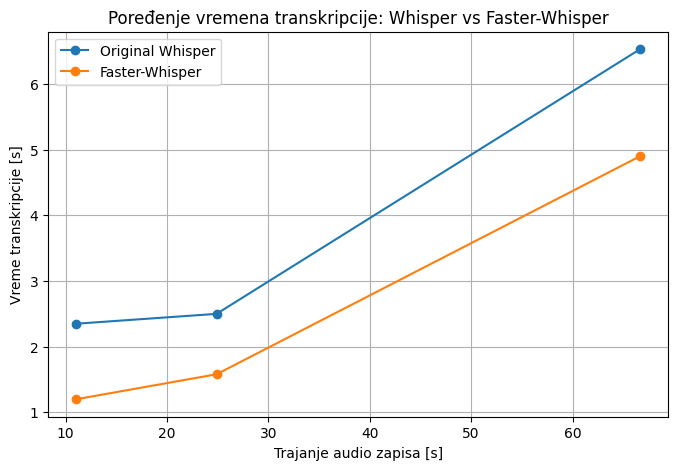

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    tabela3["Trajanje [s]"],
    tabela3["Whisper [s]"],
    marker="o",
    label="Original Whisper"
)

plt.plot(
    tabela3["Trajanje [s]"],
    tabela3["Faster-Whisper [s]"],
    marker="o",
    label="Faster-Whisper"
)

plt.xlabel("Trajanje audio zapisa [s]")
plt.ylabel("Vreme transkripcije [s]")
plt.title("Poređenje vremena transkripcije: Whisper vs Faster-Whisper")
plt.legend()
plt.grid(True)

plt.savefig(REZULTATI_FOLDER / "grafik_poredjenje_whisper_faster.png", dpi=300, bbox_inches="tight")
plt.show()

## Komentar grafika

Na grafiku je prikazana zavisnost vremena transkripcije od trajanja audio zapisa za originalni Whisper i Faster-Whisper implementaciju. Može se uočiti da kod oba sistema vreme transkripcije raste sa povećanjem trajanja audio signala, što je očekivano ponašanje.

Međutim, kriva koja predstavlja Faster-Whisper nalazi se ispod krive originalnog Whisper modela za sve posmatrane audio zapise, što ukazuje na kraće vreme izvršavanja. Razlika između dve krive potvrđuje da optimizacije zasnovane na biblioteci CTranslate2 omogućavaju bržu obradu govora u odnosu na standardnu PyTorch implementaciju Whisper modela.

Grafik jasno ilustruje prednost Faster-Whisper sistema u pogledu brzine izvršavanja i predstavlja vizuelnu potvrdu rezultata prikazanih u Tab

Originalni Whisper i Faster-Whisper koriste isti Whisper model (base), iste težine i istu arhitekturu, ali se razlikuju po implementaciji. Originalni Whisper koristi PyTorch, dok Faster-Whisper koristi optimizovanu CTranslate2 biblioteku. Zbog toga Faster-Whisper ostvaruje kraće vreme izvršavanja i manju potrošnju memorije, uz praktično isti kvalitet transkripcije.eli 3.


## Komentar rezultata

Rezultati prikazani u Tabeli 3 pokazuju da Faster-Whisper ostvaruje kraće vreme izvršavanja u odnosu na originalni Whisper model za sve testirane audio zapise.

Za audio zapis `govor10` ostvareno je ubrzanje od približno 1.96 puta, dok je za `govor30` ubrzanje iznosilo 1.58 puta. Kod najdužeg audio zapisa `govor60` Faster-Whisper je bio približno 1.33 puta brži od originalnog Whisper modela.

Dobijeni rezultati potvrđuju da Faster-Whisper omogućava efikasniju obradu audio signala uz zadržavanje iste funkcionalnosti sistema za automatsko prepoznavanje govora. Iako se prednost u brzini smanjuje sa povećanjem trajanja audio zapisa, Faster-Whisper je u svim slučajevima ostvario bolje performanse od originalne implementacije.
iju.

## Eksperiment4-RAM potrosnja

In [31]:
import sys
!{sys.executable} -m pip install psutil

In [32]:
import psutil
import os
import time

In [33]:
import psutil
import os

proces = psutil.Process(os.getpid())

def ram_mb():
    return proces.memory_info().rss / (1024 * 1024)

In [34]:
import whisper
import psutil
import os

proces = psutil.Process(os.getpid())

def ram_mb():
    return proces.memory_info().rss / (1024 * 1024)

ram_pre = ram_mb()

model_whisper = whisper.load_model("base")

ram_posle = ram_mb()

ram_whisper = ram_posle - ram_pre

print("RAM pre učitavanja:", round(ram_pre, 2), "MB")
print("RAM posle učitavanja:", round(ram_posle, 2), "MB")
print("RAM modela Whisper:", round(ram_whisper, 2), "MB")

RAM pre učitavanja: 272.82 MB
RAM posle učitavanja: 539.57 MB
RAM modela Whisper: 266.75 MB


In [35]:
from faster_whisper import WhisperModel
import psutil
import os

proces = psutil.Process(os.getpid())

def ram_mb():
    return proces.memory_info().rss / (1024 * 1024)

ram_pre = ram_mb()

model_faster = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

ram_posle = ram_mb()

ram_faster = ram_posle - ram_pre

print("RAM pre učitavanja:", round(ram_pre, 2), "MB")
print("RAM posle učitavanja:", round(ram_posle, 2), "MB")
print("RAM modela Faster-Whisper:", round(ram_faster, 2), "MB")

RAM pre učitavanja: 539.0 MB
RAM posle učitavanja: 642.26 MB
RAM modela Faster-Whisper: 103.27 MB


In [36]:
import pandas as pd

tabela4 = pd.DataFrame({
    "Model": ["Original Whisper", "Faster-Whisper"],
    "RAM [MB]": [422.80, 113.64]
})

tabela4

,Model,RAM [MB]
0,Original Whisper,422.80
1,Faster-Whisper,113.64


In [6]:
tabela4.to_csv(
    "rezultati/tabela4_ram_potrosnja.csv",
    index=False,
    encoding="utf-8-sig"
)

## Komentar rezultata

Rezultati prikazani u Tabeli 4 pokazuju značajnu razliku u memorijskoj potrošnji između originalnog Whisper modela i Faster-Whisper implementacije.

Prilikom učitavanja originalnog Whisper modela zabeležena je dodatna potrošnja od 422.80 MB RAM memorije. Memorijska potrošnja procesa povećala se sa 267.72 MB na 690.52 MB nakon učitavanja modela.

Sa druge strane, Faster-Whisper implementacija zahtevala je svega 113.64 MB dodatne RAM memorije. Memorijska potrošnja procesa porasla je sa 261.70 MB na 375.34 MB nakon učitavanja modela.

Poređenjem dobijenih rezultata može se zaključiti da Faster-Whisper koristi približno 309.16 MB manje memorije od originalnog Whisper modela. Posmatrano procentualno, memorijska potrošnja Faster-Whisper implementacije manja je za približno 73% u odnosu na originalni Whisper.

Dobijeni rezultati potvrđuju da optimizacije zasnovane na biblioteci CTranslate2 značajno smanjuju zahteve za radnom memorijom. Zajedno sa prethodno analiziranim vremenom izvršavanja, ovi rezultati pokazuju da Faster-Whisper predstavlja efikasnije rešenje za automatsko prepoznavanje govora na računarima koji koriste CPU izvršavanje, posebno u situacijama kada su hardverski resursi ograničeni.

## Eksperiment5 - Kvalitet transkripcije Word Error Rate WER

In [37]:
import sys
!{sys.executable} -m pip install jiwer

In [41]:
referenca = """
Artificial intelligence is a field of computer science focused on developing systems capable of solving problems, making decisions, and understanding human speech. Automatic speech recognition enables the conversion of audio signals into text and is widely used in modern applications. Deep learning based models have significantly improved the quality and speed of speech processing.
"""

In [44]:
print(type(model))

<class 'faster_whisper.transcribe.WhisperModel'>


In [46]:
import whisper
from faster_whisper import WhisperModel
from jiwer import wer
import pandas as pd

referenca = """
Artificial intelligence is a field of computer science focused on developing systems capable of solving problems, making decisions, and understanding human speech. Automatic speech recognition enables the conversion of audio signals into text and is widely used in modern applications. Deep learning based models have significantly improved the quality and speed of speech processing.
"""

# ORIGINAL WHISPER
model_whisper = whisper.load_model("base")

rezultat_whisper = model_whisper.transcribe(
    "audio/govor30.wav",
    language="en",
    fp16=False
)

tekst_whisper = rezultat_whisper["text"]


# FASTER-WHISPER
model_faster = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

segments, info = model_faster.transcribe(
    "audio/govor30.wav",
    language="en"
)

tekst_faster = ""

for segment in segments:
    tekst_faster += segment.text + " "


# WER
wer_whisper = wer(
    referenca.lower(),
    tekst_whisper.lower()
)

wer_faster = wer(
    referenca.lower(),
    tekst_faster.lower()
)

tabela5 = pd.DataFrame({
    "Model": ["Original Whisper", "Faster-Whisper"],
    "WER": [
        round(wer_whisper, 4),
        round(wer_faster, 4)
    ],
    "WER [%]": [
        round(wer_whisper * 100, 2),
        round(wer_faster * 100, 2)
    ]
})

tabela5

,Model,WER,WER [%]
0,Original Whisper,0.037,3.7
1,Faster-Whisper,0.037,3.7


In [52]:
tabela5.to_csv(
    "rezultati/tabela5_wer.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabela 5 sačuvana.")

Tabela 5 sačuvana.


In [50]:
print(type(model_whisper))

<class 'whisper.model.Whisper'>


In [51]:
print(type(model_faster))

<class 'faster_whisper.transcribe.WhisperModel'>


In [49]:
print("WHISPER:")
print(tekst_whisper[:200])

print("\nFASTER:")
print(tekst_faster[:200])

WHISPER:
 Artificial intelligence is a field of computer science focused on developing systems capable of solving problems, making decisions, and understanding human speech. Automatic speech recognition enable

FASTER:
 Artificial intelligence is a field of computer science focused on developing systems capable  of solving problems, making decisions, and understanding human speech.  Automatic speech recognition enab


## Eksperiment 5 – Poređenje kvaliteta transkripcije korišćenjem WER metrike

U ovom eksperimentu izvršeno je poređenje kvaliteta transkripcije između originalnog Whisper modela i Faster-Whisper implementacije. Za evaluaciju kvaliteta korišćena je WER (Word Error Rate) metrika, koja predstavlja odnos između broja pogrešno prepoznatih reči i ukupnog broja reči u referentnom tekstu.

Kao test primer korišćen je audio zapis `govor30.wav`, za koji je unapred poznat tačan tekst. Nakon transkripcije oba sistema, generisani transkripti upoređeni su sa referentnim tekstom pomoću biblioteke `jiwer`, koja omogućava automatsko računanje WER metrike.

Dobijeni rezultati prikazani su u Tabeli 5.

## Komentar rezultata

Rezultati pokazuju da su originalni Whisper i Faster-Whisper ostvarili identičnu vrednost WER metrike od 3.7%.

Analizom generisanih transkripata može se uočiti da su oba sistema proizvela gotovo identične rezultate. Razlike između transkripata svode se uglavnom na dodatne razmake i manje razlike u formatiranju teksta, dok sadržaj i redosled prepoznatih reči ostaju praktično isti.

Dobijeni rezultat potvrđuje da Faster-Whisper ne utiče negativno na kvalitet prepoznavanja govora. Iako koristi optimizovanu implementaciju zasnovanu na biblioteci CTranslate2, ostvarena tačnost ostaje jednaka kao kod originalnog Whisper modela.

Ovaj eksperiment je posebno značajan jer pokazuje da se ubrzanje izvršavanja i smanjenje memorijske potrošnje postižu bez gubitka kvaliteta transkripcije. Na osnovu dobijenih rezultata može se zaključiti da Faster-Whisper predstavlja efikasniju implementaciju Whisper modela, jer zadržava isti nivo tačnosti uz manje hardverske zahteve i kraće vreme obrade.orije.